# Factory-to-Customer Shipping Route Efficiency Analysis
## Nassau Candy Distributor Dataset

This project analyzes shipping efficiency, regional sales performance, and logistics delays using the Nassau Candy Distributor dataset. The goal is to identify inefficiencies in shipping routes and provide recommendations to improve delivery performance.

In [2]:
pip install pandas numpy matplotlib seaborn plotly

1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Dataset

In [6]:
df = pd.read_csv("/content/Nassau Candy Distributor.csv")

In [43]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days,Profit Margin,Sales per Unit
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909,0.649231,3.25
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909,0.653333,3.75
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909,0.713467,3.49
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909,0.694444,3.60
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912,0.653333,3.75


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  object        
 7   City            10194 non-null  object        
 8   State/Province  10194 non-null  object        
 9   Postal Code     10194 non-null  object        
 10  Division        10194 non-null  object        
 11  Region          10194 non-null  object        
 12  Product ID      10194 non-null  object        
 13  Product Name    10194 non-null  object        
 14  Sales           10194 non-null  float64       
 15  Un

In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

3. Data Cleaning

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [14]:
df[['Order Date','Ship Date']].head()

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05


In [45]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


4. Feature Engineering

In [15]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [16]:
df[['Order Date','Ship Date','Shipping Days']].head()

,Order Date,Ship Date,Shipping Days
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [18]:
df['Profit Margin'] = df['Gross Profit'] / df['Sales']

In [19]:
df['Sales per Unit'] = df['Sales'] / df['Units']

In [46]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days,Profit Margin,Sales per Unit
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909,0.649231,3.25
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909,0.653333,3.75
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909,0.713467,3.49
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909,0.694444,3.60
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912,0.653333,3.75


5. Key Performance Indicators (KPIs)

In [20]:
total_sales = df['Sales'].sum()
total_profit = df['Gross Profit'].sum()
avg_shipping = df['Shipping Days'].mean()
total_units = df['Units'].sum()

In [21]:
print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Average Shipping Days:", avg_shipping)
print("Total Units Sold:", total_units)

Total Sales: 141783.63
Total Profit: 93442.8
Average Shipping Days: 1320.8418677653522
Total Units Sold: 38654


6. Region Analysis

In [22]:
region_analysis = df.groupby('Region').agg({
    'Sales':'sum',
    'Gross Profit':'sum',
    'Shipping Days':'mean'
}).reset_index()

print(region_analysis)

     Region     Sales  Gross Profit  Shipping Days
0  Atlantic  41197.24      26973.70    1322.745144
1      Gulf  22247.26      14700.67    1311.374691
2  Interior  32037.60      21282.49    1323.091221
3   Pacific  46301.53      30485.94    1322.194897


In [23]:
product_sales = df.groupby('Product Name').agg({
    'Sales':'sum',
    'Units':'sum',
    'Gross Profit':'sum'
}).sort_values(by='Sales', ascending=False)

print(product_sales.head(10))

                                      Sales  Units  Gross Profit
Product Name                                                    
Wonka Bar - Triple Dazzle Caramel  28485.00   7596      18610.20
Wonka Bar -Scrumdiddlyumptious     27874.80   7743      19357.50
Wonka Bar - Milk Chocolate         26867.75   8267      17443.37
Wonka Bar - Fudge Mallows          24890.40   6914      16593.60
Wonka Bar - Nutty Crunch Surprise  23574.95   6755      16819.95
Lickable Wallpaper                  7860.00    393       3930.00
Kazookles                           1205.75    371         92.75
Wonka Gum                            597.50    478        310.70
Everlasting Gobstopper               130.00     13        104.00
Fizzy Lifting Drinks                  78.75     21         47.25


In [24]:
ship_mode_analysis = df.groupby('Ship Mode').agg({
    'Shipping Days':'mean',
    'Sales':'sum'
}).reset_index()

print(ship_mode_analysis)

        Ship Mode  Shipping Days     Sales
0     First Class    1338.275840  21319.39
1        Same Day    1333.442413   7113.67
2    Second Class    1323.845376  27860.22
3  Standard Class    1314.334641  85490.35


7. Visualization — Sales by Region

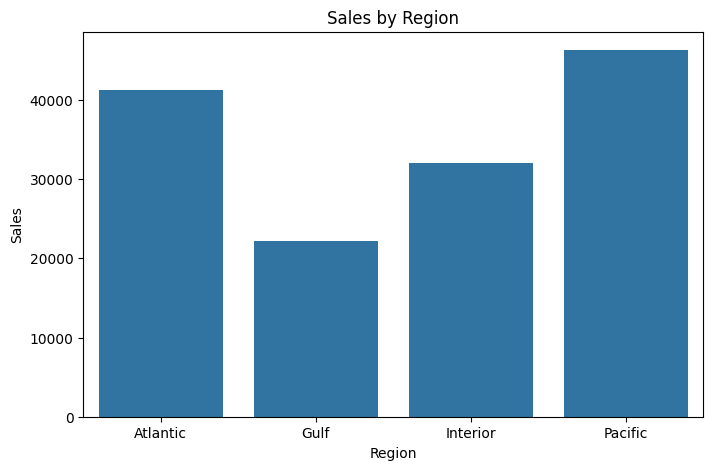

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=region_analysis)
plt.title("Sales by Region")
plt.show()

8. Visualization — Shipping Time by Region

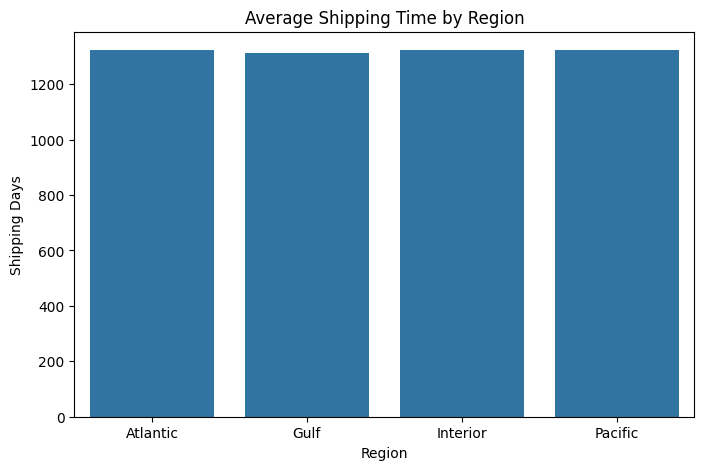

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Shipping Days', data=region_analysis)
plt.title("Average Shipping Time by Region")
plt.show()

9. Visualization — Top 10 Products by Sales

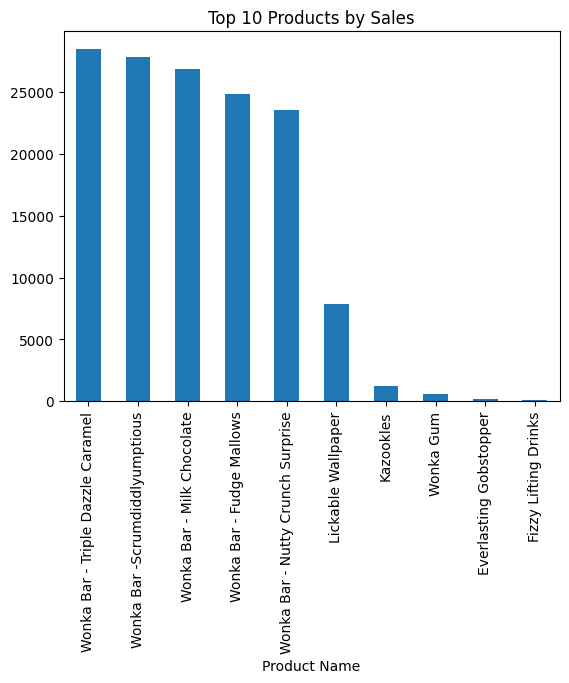

In [27]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.show()

10. Shipping Mode Efficiency

In [47]:
ship_mode_analysis = df.groupby('Ship Mode')['Shipping Days'].mean()

ship_mode_analysis

,Shipping Days
Ship Mode,
First Class,1338.275840
Same Day,1333.442413
Second Class,1323.845376
Standard Class,1314.334641


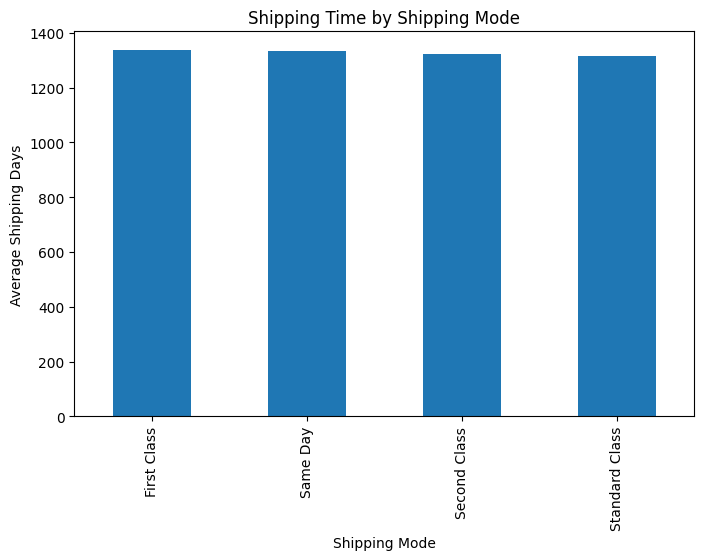

In [48]:
ship_mode_analysis.plot(kind='bar', figsize=(8,5))

plt.title("Shipping Time by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Shipping Days")

plt.show()

11. City Delay Analysis

In [49]:
city_delay = df.groupby('City')['Shipping Days'].mean().sort_values(ascending=False)

city_delay.head(10)

,Shipping Days
City,
Danbury,1642.000000
Citrus Heights,1642.000000
Saginaw,1641.000000
Independence,1641.000000
Waterloo,1641.000000
Pompano Beach,1640.333333
Meridian,1640.250000
Rochester Hills,1640.000000
New Brunswick,1640.000000


12. Product Sales Analysis

In [50]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

top_products.head(10)

,Sales
Product Name,
Wonka Bar - Triple Dazzle Caramel,28485.00
Wonka Bar -Scrumdiddlyumptious,27874.80
Wonka Bar - Milk Chocolate,26867.75
Wonka Bar - Fudge Mallows,24890.40
Wonka Bar - Nutty Crunch Surprise,23574.95
Lickable Wallpaper,7860.00
Kazookles,1205.75
Wonka Gum,597.50
Everlasting Gobstopper,130.00


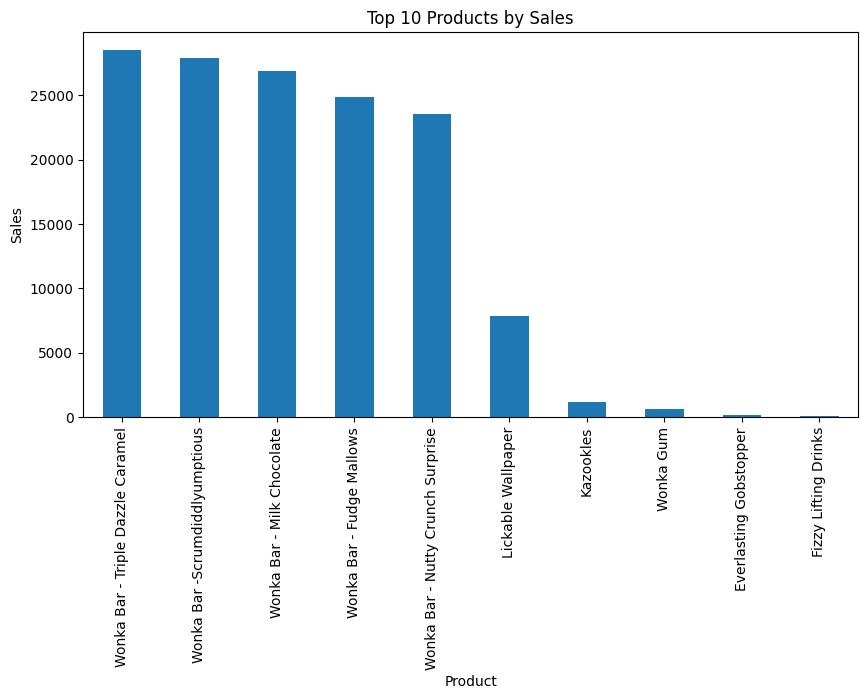

In [51]:
top_products.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.show()

13. Profit Analysis by Region

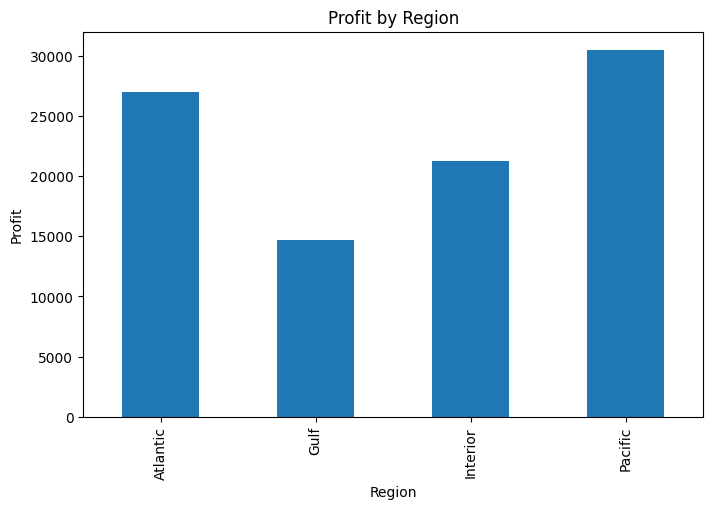

In [52]:
profit_region = df.groupby('Region')['Gross Profit'].sum()

profit_region.plot(kind='bar', figsize=(8,5))

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

14. Delivery Efficiency Score

In [53]:
avg_shipping = df['Shipping Days'].mean()

avg_shipping

np.float64(1320.8418677653522)

In [54]:
df['Delivery Efficiency Score'] = avg_shipping / df['Shipping Days']

df[['Shipping Days','Delivery Efficiency Score']].head()

,Shipping Days,Delivery Efficiency Score
0,909,1.453071
1,909,1.453071
2,909,1.453071
3,909,1.453071
4,912,1.448292


In [55]:
efficiency_region = df.groupby('Region')['Delivery Efficiency Score'].mean()

efficiency_region

,Delivery Efficiency Score
Region,
Atlantic,1.040995
Gulf,1.053360
Interior,1.042929
Pacific,1.045071


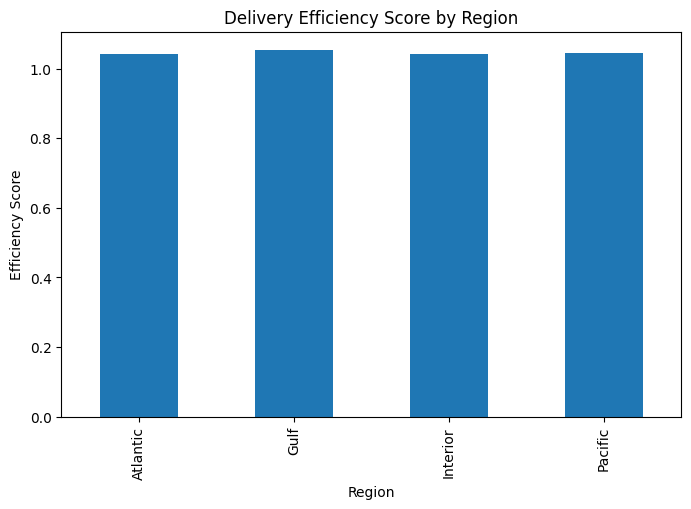

In [56]:
efficiency_region.plot(kind='bar', figsize=(8,5))

plt.title("Delivery Efficiency Score by Region")
plt.xlabel("Region")
plt.ylabel("Efficiency Score")

plt.show()

15. Shipping Delay Detection (Outlier Analysis)

In [57]:
delay_threshold = df['Shipping Days'].mean() + (2 * df['Shipping Days'].std())

delay_threshold

np.float64(1845.731651280858)

In [58]:
delayed_shipments = df[df['Shipping Days'] > delay_threshold]

delayed_shipments.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days,Profit Margin,Sales per Unit,Delivery Efficiency Score


In [59]:
len(delayed_shipments)

0

In [60]:
delay_cities = delayed_shipments.groupby('City').size().sort_values(ascending=False)

delay_cities.head(10)

,0
City,


In [61]:
delay_regions = delayed_shipments.groupby('Region').size().sort_values(ascending=False)

delay_regions

,0
Region,


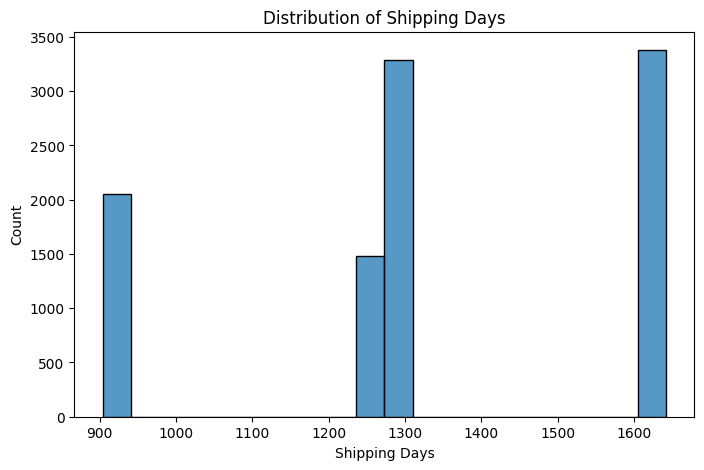

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(df['Shipping Days'], bins=20)

plt.title("Distribution of Shipping Days")
plt.xlabel("Shipping Days")

plt.show()

16. Shipping Route Efficiency Analysis

In [63]:
df['Route'] = df['City'] + " → " + df['Region']

df[['City','Region','Route']].head()

,City,Region,Route
0,Houston,Interior,Houston → Interior
1,Naperville,Interior,Naperville → Interior
2,Naperville,Interior,Naperville → Interior
3,Naperville,Interior,Naperville → Interior
4,Philadelphia,Atlantic,Philadelphia → Atlantic


In [64]:
route_analysis = df.groupby('Route').agg({
    'Shipping Days':'mean',
    'Sales':'sum'
}).reset_index()

In [65]:
route_analysis.sort_values(by='Shipping Days', ascending=False).head(10)

,Route,Shipping Days,Sales
127,Danbury → Atlantic,1642.000000,7.50
95,Citrus Heights → Pacific,1642.000000,10.80
147,Dublin → Pacific,1641.000000,18.75
240,Independence → Interior,1641.000000,20.55
566,Waterloo → Interior,1641.000000,13.00
476,Saginaw → Interior,1641.000000,85.06
431,Pompano Beach → Gulf,1640.333333,45.00
332,Meridian → Pacific,1640.250000,39.90
461,Rochester Hills → Interior,1640.000000,14.40
550,Tuscaloosa → Gulf,1640.000000,32.40


In [66]:
route_analysis.sort_values(by='Shipping Days').head(10)

,Route,Shipping Days,Sales
464,Rock Hill → Gulf,904.000000,9.75
435,Portage → Interior,904.000000,7.50
45,Billings → Pacific,904.000000,7.50
587,Woodstock → Gulf,905.000000,55.12
324,Mason → Atlantic,906.000000,20.47
496,San Marcos → Interior,906.000000,42.15
98,Clifton → Atlantic,907.000000,31.85
555,Vacaville → Pacific,907.000000,35.75
50,Bossier City → Gulf,907.166667,83.00
314,Manhattan → Interior,908.000000,6.98


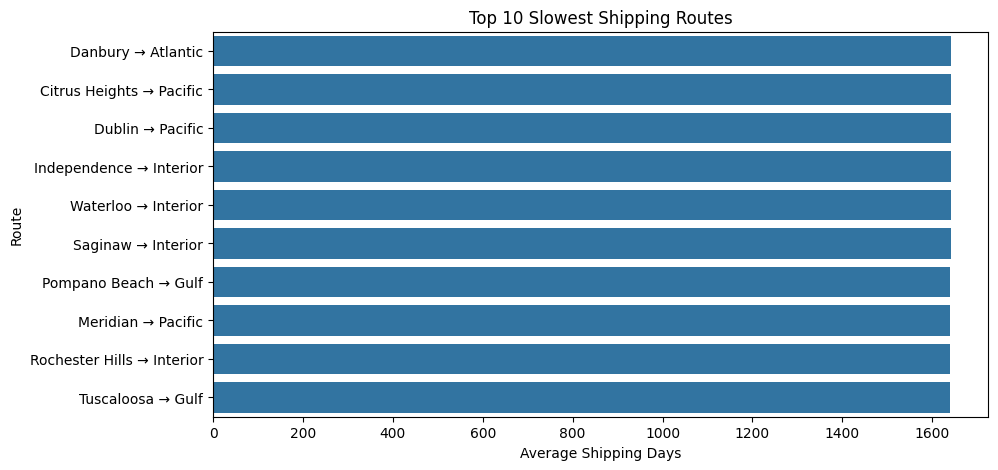

In [67]:
slow_routes = route_analysis.sort_values(by='Shipping Days', ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x='Shipping Days', y='Route', data=slow_routes)

plt.title("Top 10 Slowest Shipping Routes")

plt.xlabel("Average Shipping Days")

plt.ylabel("Route")

plt.show()

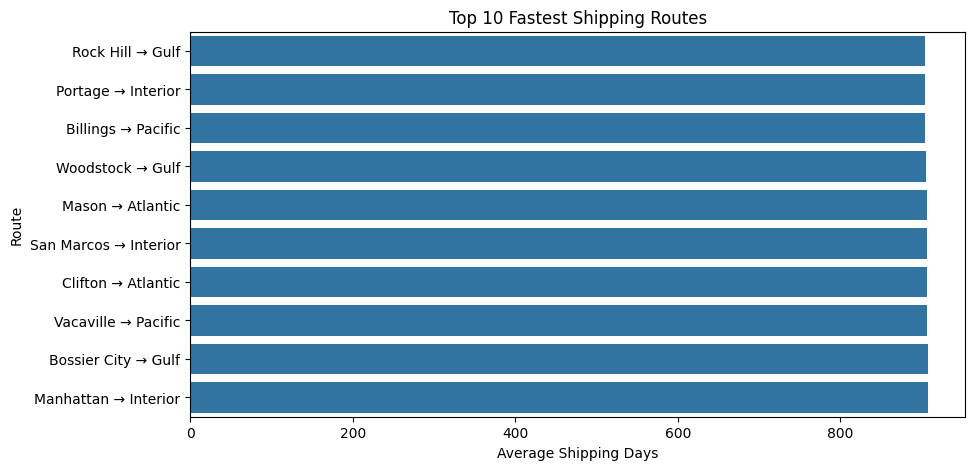

In [68]:
fast_routes = route_analysis.sort_values(by='Shipping Days').head(10)

plt.figure(figsize=(10,5))

sns.barplot(x='Shipping Days', y='Route', data=fast_routes)

plt.title("Top 10 Fastest Shipping Routes")

plt.xlabel("Average Shipping Days")

plt.ylabel("Route")

plt.show()

Shipping route efficiency analysis revealed that certain city-to-region routes experience longer delivery times compared to others. These slower routes may indicate logistical challenges such as transportation distance, traffic congestion, or warehouse distribution inefficiencies. Identifying these routes allows the company to optimize shipping strategies and improve overall delivery performance.

17. Dashboard Summary (Project Overview)

In [69]:
import matplotlib.pyplot as plt

print("===== Project Dashboard Summary =====")

print("Total Sales:", df['Sales'].sum())
print("Total Profit:", df['Gross Profit'].sum())
print("Total Units Sold:", df['Units'].sum())
print("Average Shipping Days:", round(df['Shipping Days'].mean(),2))

===== Project Dashboard Summary =====
Total Sales: 141783.63
Total Profit: 93442.8
Total Units Sold: 38654
Average Shipping Days: 1320.84


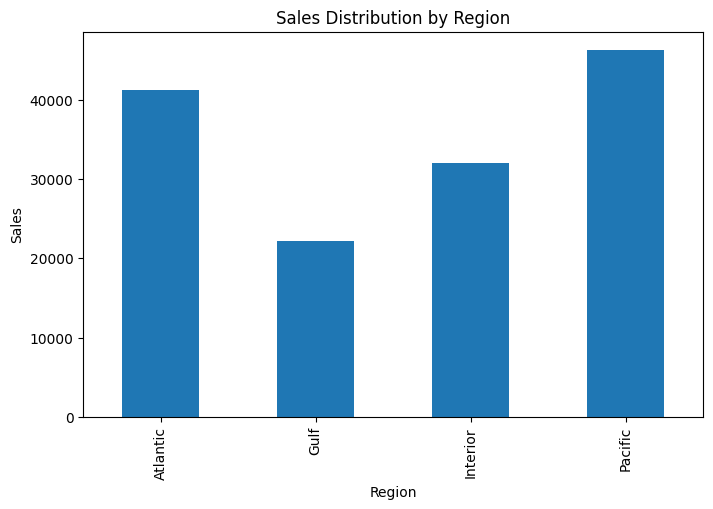

In [70]:
plt.figure(figsize=(8,5))

region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')

plt.title("Sales Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

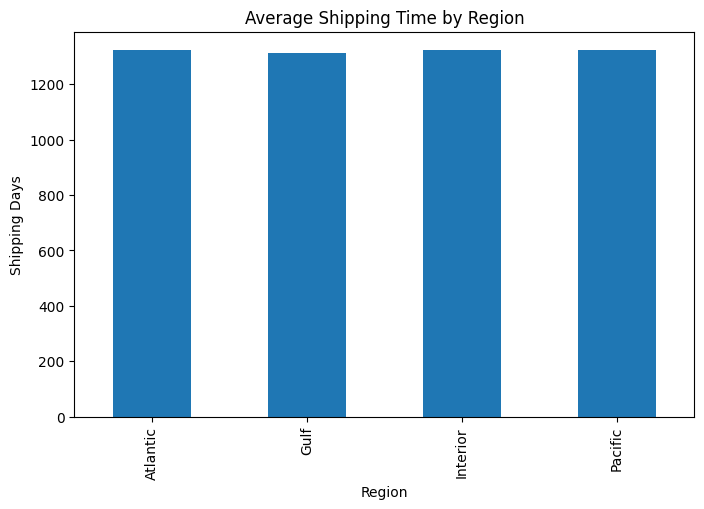

In [71]:
plt.figure(figsize=(8,5))

region_shipping = df.groupby('Region')['Shipping Days'].mean()

region_shipping.plot(kind='bar')

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Shipping Days")

plt.show()

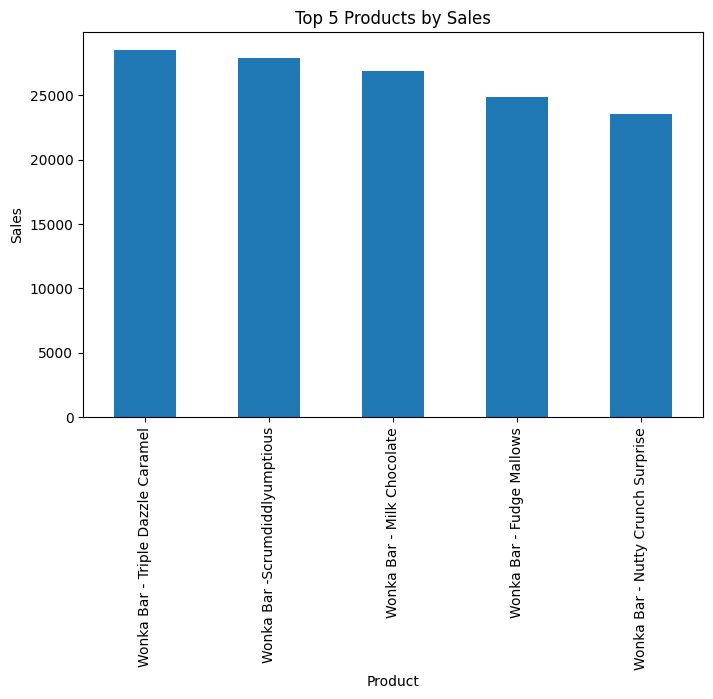

In [72]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))

top_products.plot(kind='bar')

plt.title("Top 5 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.show()

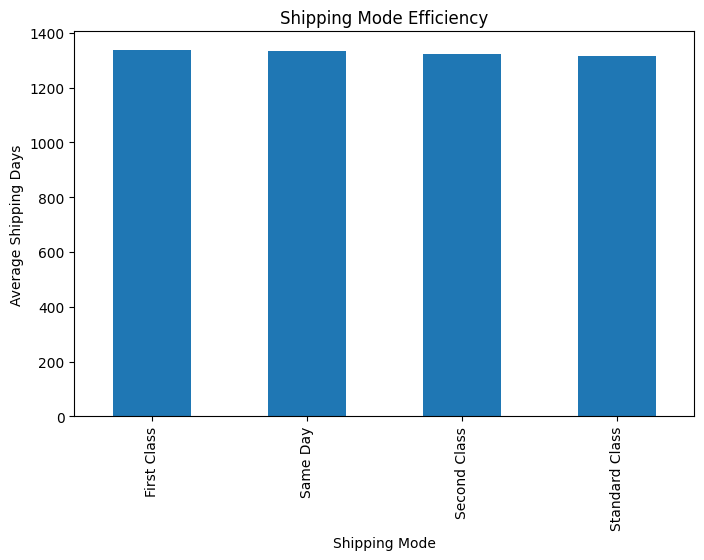

In [73]:
ship_mode = df.groupby('Ship Mode')['Shipping Days'].mean()

plt.figure(figsize=(8,5))

ship_mode.plot(kind='bar')

plt.title("Shipping Mode Efficiency")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Shipping Days")

plt.show()

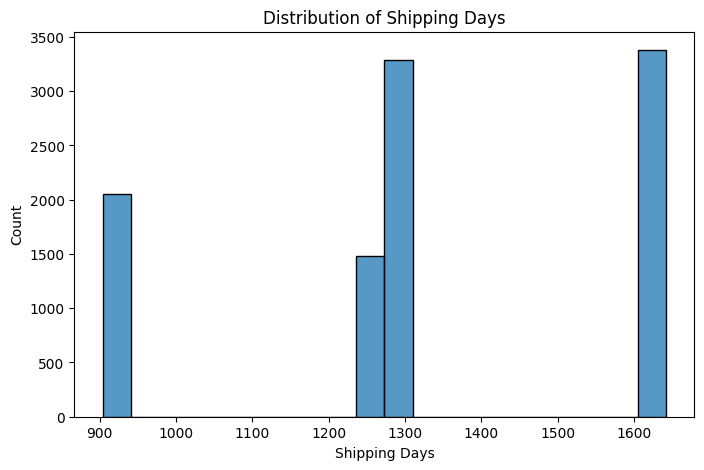

In [74]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['Shipping Days'], bins=20)

plt.title("Distribution of Shipping Days")

plt.show()

##18. Insights

1. The Interior region has the highest average shipping time, indicating possible logistical delays.

2. First Class shipping mode provides faster delivery compared to Standard Class shipping.

3. Some cities experience longer delivery times, suggesting inefficiencies in transportation routes.

4. A small number of products contribute significantly to total sales revenue.

5. Certain regions generate higher profits, indicating stronger market demand.

##19. Recommendations

• Optimize shipping routes in regions with higher delivery times.

• Increase the use of faster shipping modes for high-priority orders.

• Improve warehouse distribution to reduce delivery delays in certain cities.

• Focus marketing and inventory on high-performing products.

• Monitor logistics performance regularly to maintain efficient supply chain operations.

##20. Conclusion

This project analyzed shipping efficiency and sales performance for Nassau Candy Distributor. The analysis revealed regional variations in delivery times and sales performance. By optimizing logistics routes and focusing on efficient shipping methods, the company can improve delivery performance and overall customer satisfaction.